# Day 3 — Few-shot Adaptation for B5 Methane Calibration Transfer

This notebook uses the Day 2 feature table and implements lightweight, interpretable calibration-transfer adaptation methods. It does **not** redo Day 1 or Day 2.

## Scientific questions

1. How much B5 data is needed?
2. Does adaptation mainly fix baseline shift, gain mismatch, nonlinear distortion, or saturation mismatch?
3. Which adaptation method is most data-efficient?
4. Do physics-informed features reduce adaptation burden?
5. Does high-concentration transfer remain difficult?

In [1]:
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import day3_adaptation
importlib.reload(day3_adaptation)

from day3_adaptation import run_day3, get_paths

In [2]:
from day3_adaptation import run_day3, get_paths

paths = get_paths(PROJECT_ROOT)
paths.results_dir.mkdir(parents=True, exist_ok=True)
paths.figures_dir.mkdir(parents=True, exist_ok=True)
print(paths)

ProjectPaths(root=WindowsPath('C:/Users/hg/PycharmProjects/mox_calibration_transfer'), feature_table=WindowsPath('C:/Users/hg/PycharmProjects/mox_calibration_transfer/results/day2/feature_table_methane.csv'), results_dir=WindowsPath('C:/Users/hg/PycharmProjects/mox_calibration_transfer/results/day3'), figures_dir=WindowsPath('C:/Users/hg/PycharmProjects/mox_calibration_transfer/figures/day3'))


## Run Day 3 adaptation experiment

The default primary feature set is `physics`. The script falls back to all numeric features only if too few physics-like columns are detected.

In [3]:
metrics, predictions = run_day3(root=PROJECT_ROOT, feature_mode='physics')
metrics.head()

[Leakage check] shots=0, adapt=0, holdout=20, overlap=0
[Leakage check] shots=1, adapt=10, holdout=10, overlap=0
[Leakage check] shots=2, adapt=10, holdout=10, overlap=0
[Leakage check] shots=5, adapt=10, holdout=10, overlap=0
[Leakage check] shots=10, adapt=10, holdout=10, overlap=0
[Leakage check] shots=5, adapt=10, holdout=10, overlap=0


,shots_per_concentration,n_adapt,n_holdout,method,rmse,mae,r2,accuracy_from_regression_bins,high_concentration_rmse,feature_mode,n_features
3,0,0,20,centroid_alignment,6.346328,3.634842,0.951181,0.8,11.22511,physics,89
5,0,0,20,coral_alignment,6.346328,3.634842,0.951181,0.8,11.22511,physics,89
1,0,0,20,linear_recalibration,6.346328,3.634842,0.951181,0.8,11.22511,physics,89
4,0,0,20,mean_std_alignment,6.346328,3.634842,0.951181,0.8,11.22511,physics,89
0,0,0,20,no_adaptation,6.346328,3.634842,0.951181,0.8,11.22511,physics,89


In [4]:
metrics.sort_values(['shots_per_concentration', 'rmse']).groupby('shots_per_concentration').head(3)

,shots_per_concentration,n_adapt,n_holdout,method,rmse,mae,r2,accuracy_from_regression_bins,high_concentration_rmse,feature_mode,n_features
3,0,0,20,centroid_alignment,6.346328,3.634842,0.951181,0.8,11.225110,physics,89
5,0,0,20,coral_alignment,6.346328,3.634842,0.951181,0.8,11.225110,physics,89
1,0,0,20,linear_recalibration,6.346328,3.634842,0.951181,0.8,11.225110,physics,89
12,1,10,10,rf_retraining,2.610437,1.957423,0.991740,1.0,3.227060,physics,89
13,1,10,10,rf_weighted_retraining,2.618374,1.979804,0.991690,0.9,2.764155,physics,89
6,1,10,10,no_adaptation,3.315966,2.169250,0.986672,0.8,5.782580,physics,89
17,2,10,10,centroid_alignment,6.101859,3.450860,0.954869,0.8,10.768936,physics,89
18,2,10,10,mean_std_alignment,6.168901,3.597039,0.953872,0.8,10.894333,physics,89
15,2,10,10,linear_recalibration,6.734718,4.472746,0.945023,0.6,11.175924,physics,89
26,5,10,10,mean_std_alignment,1.171812,0.932542,0.998336,1.0,1.401149,physics,89


## Key figures


 rmse_vs_fewshot_samples.png


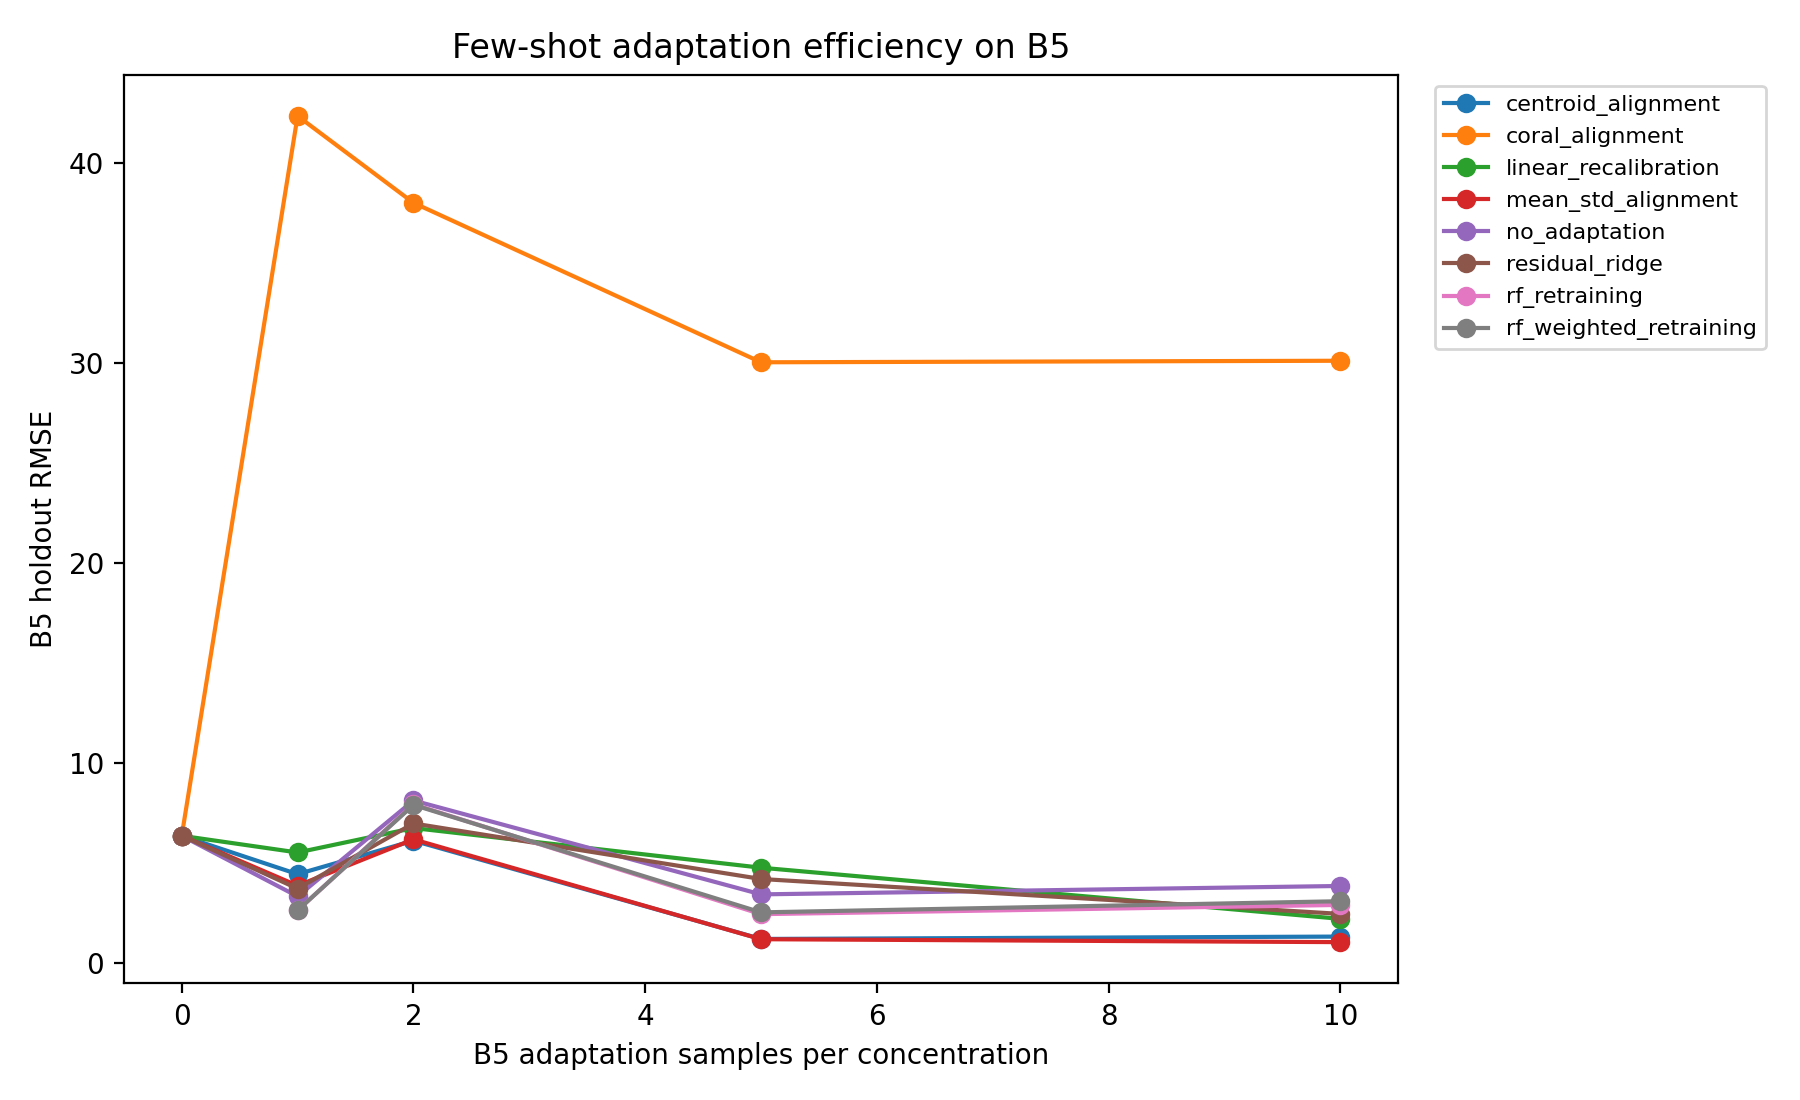


 prediction_vs_true_best_adaptation.png


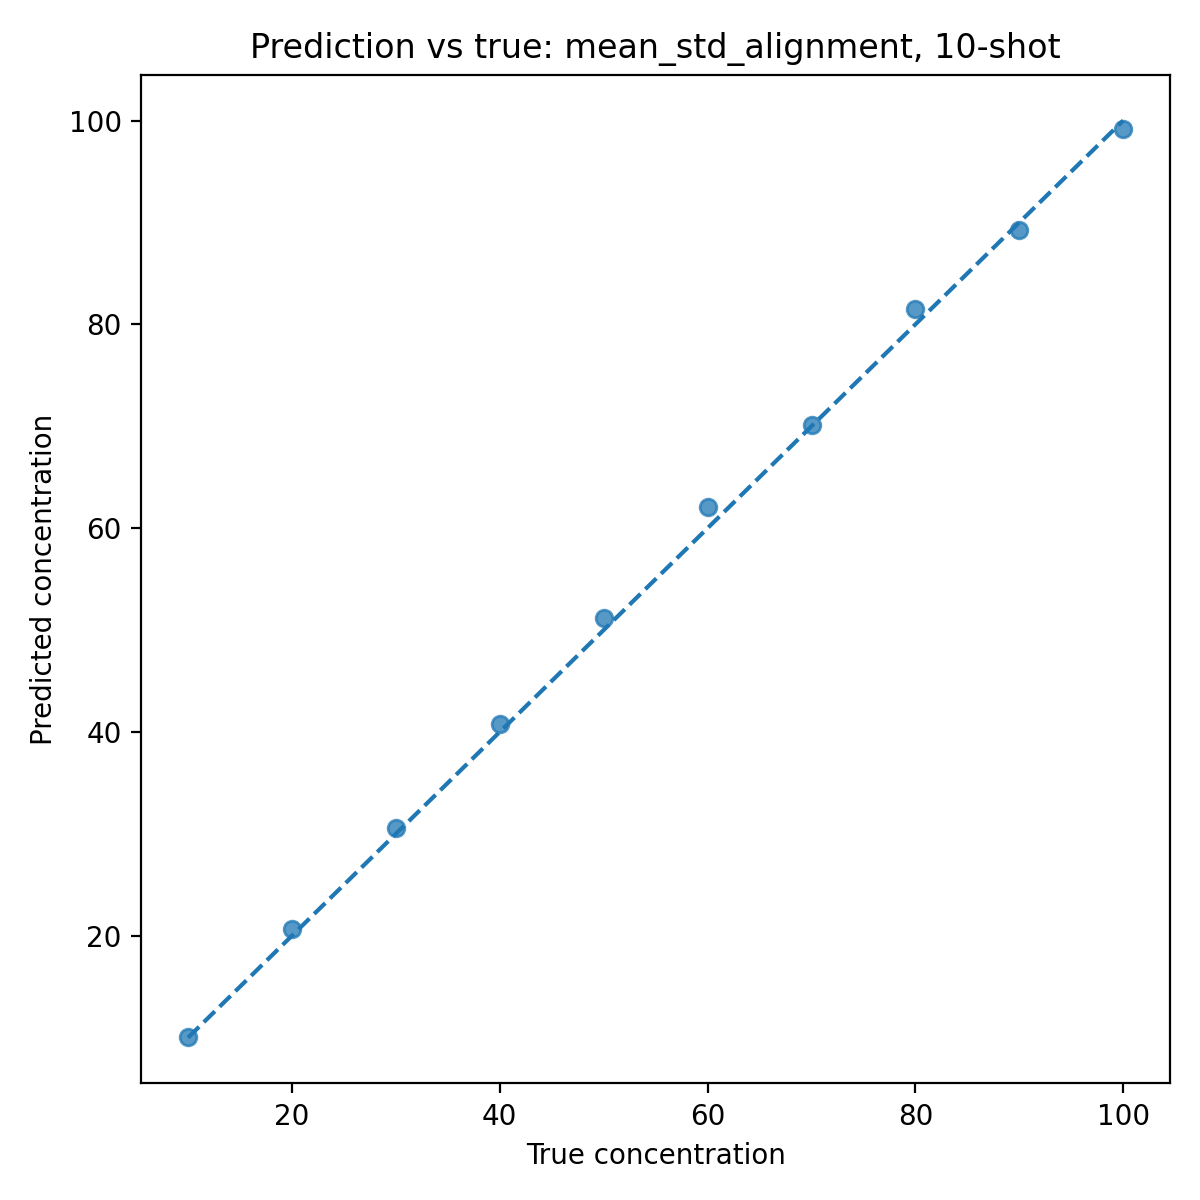


 pca_before_adaptation.png


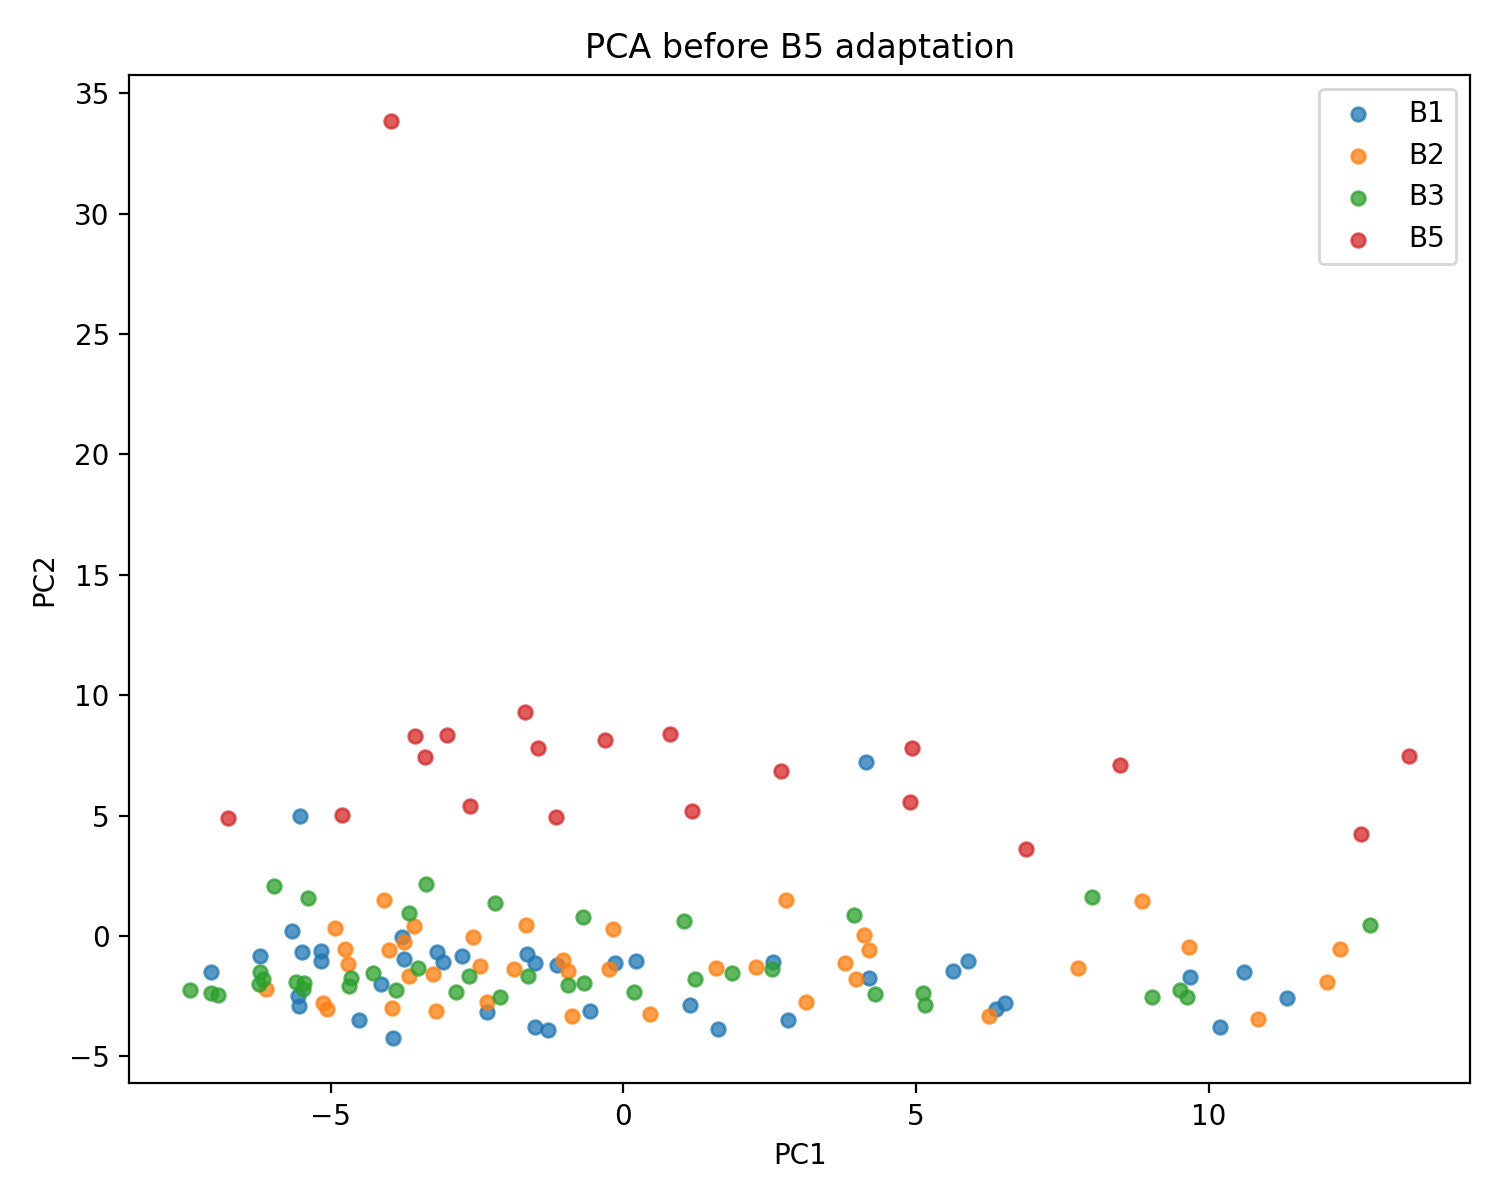


 pca_after_mean_std_alignment.png


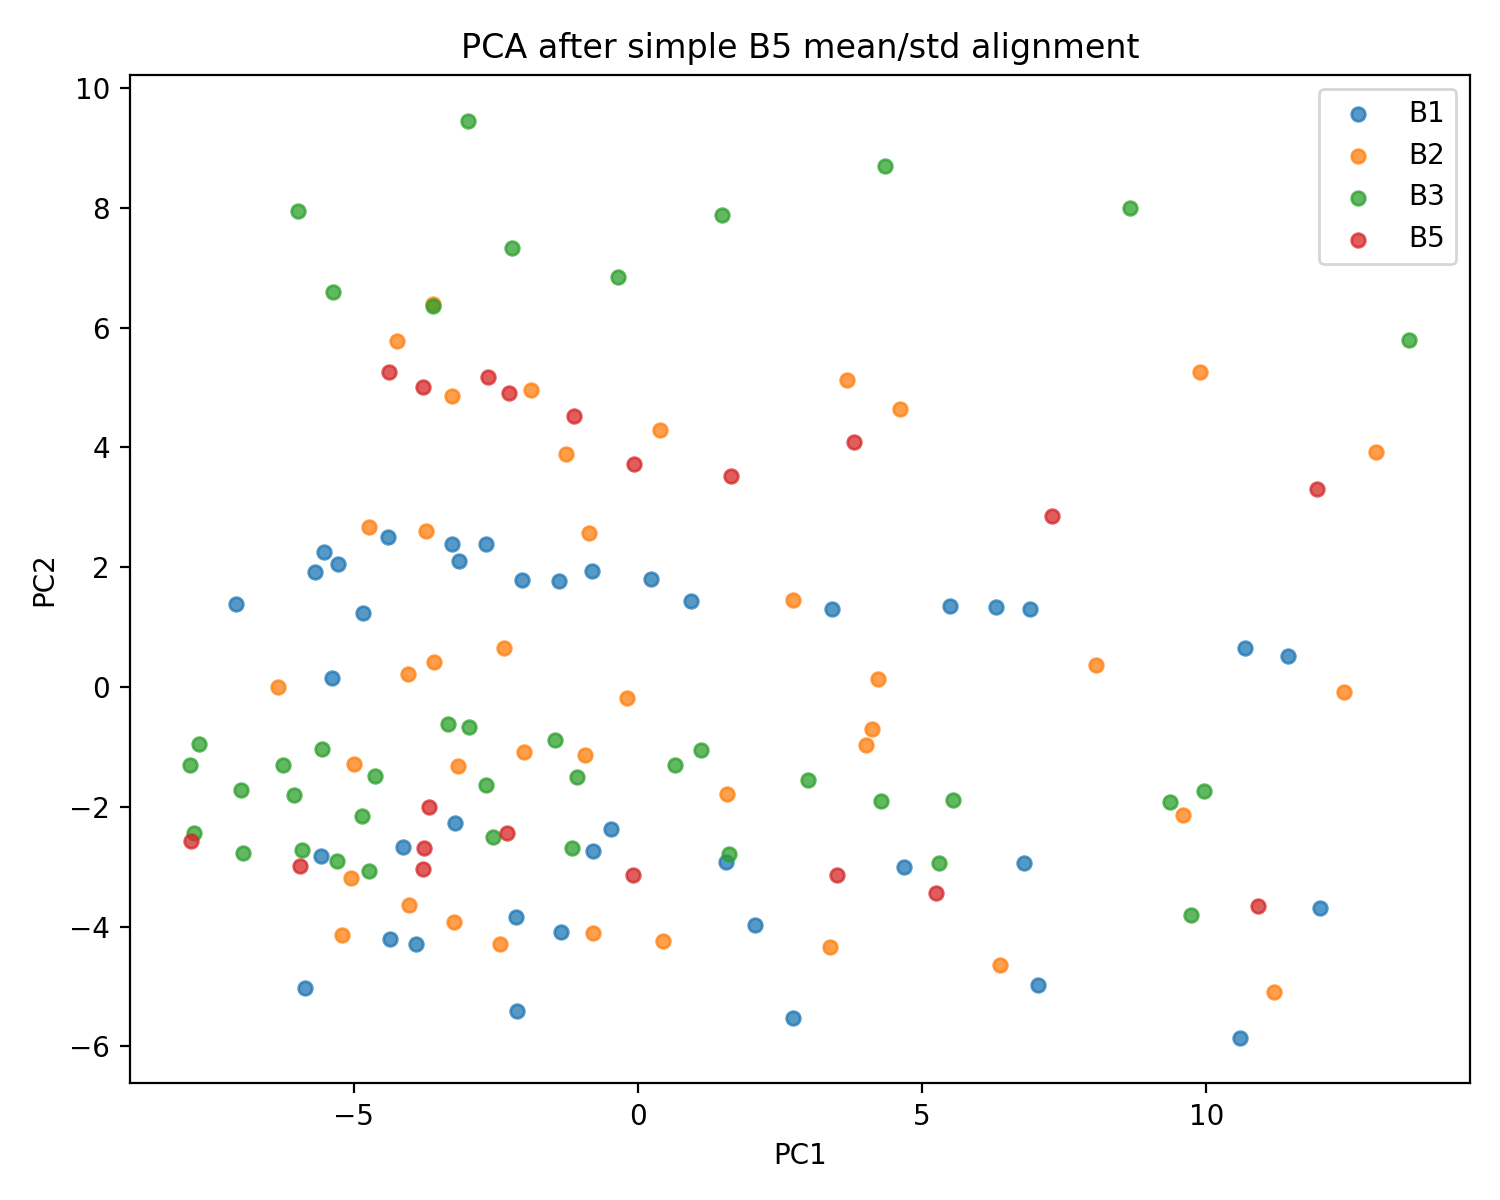


 feature_distribution_alignment.png


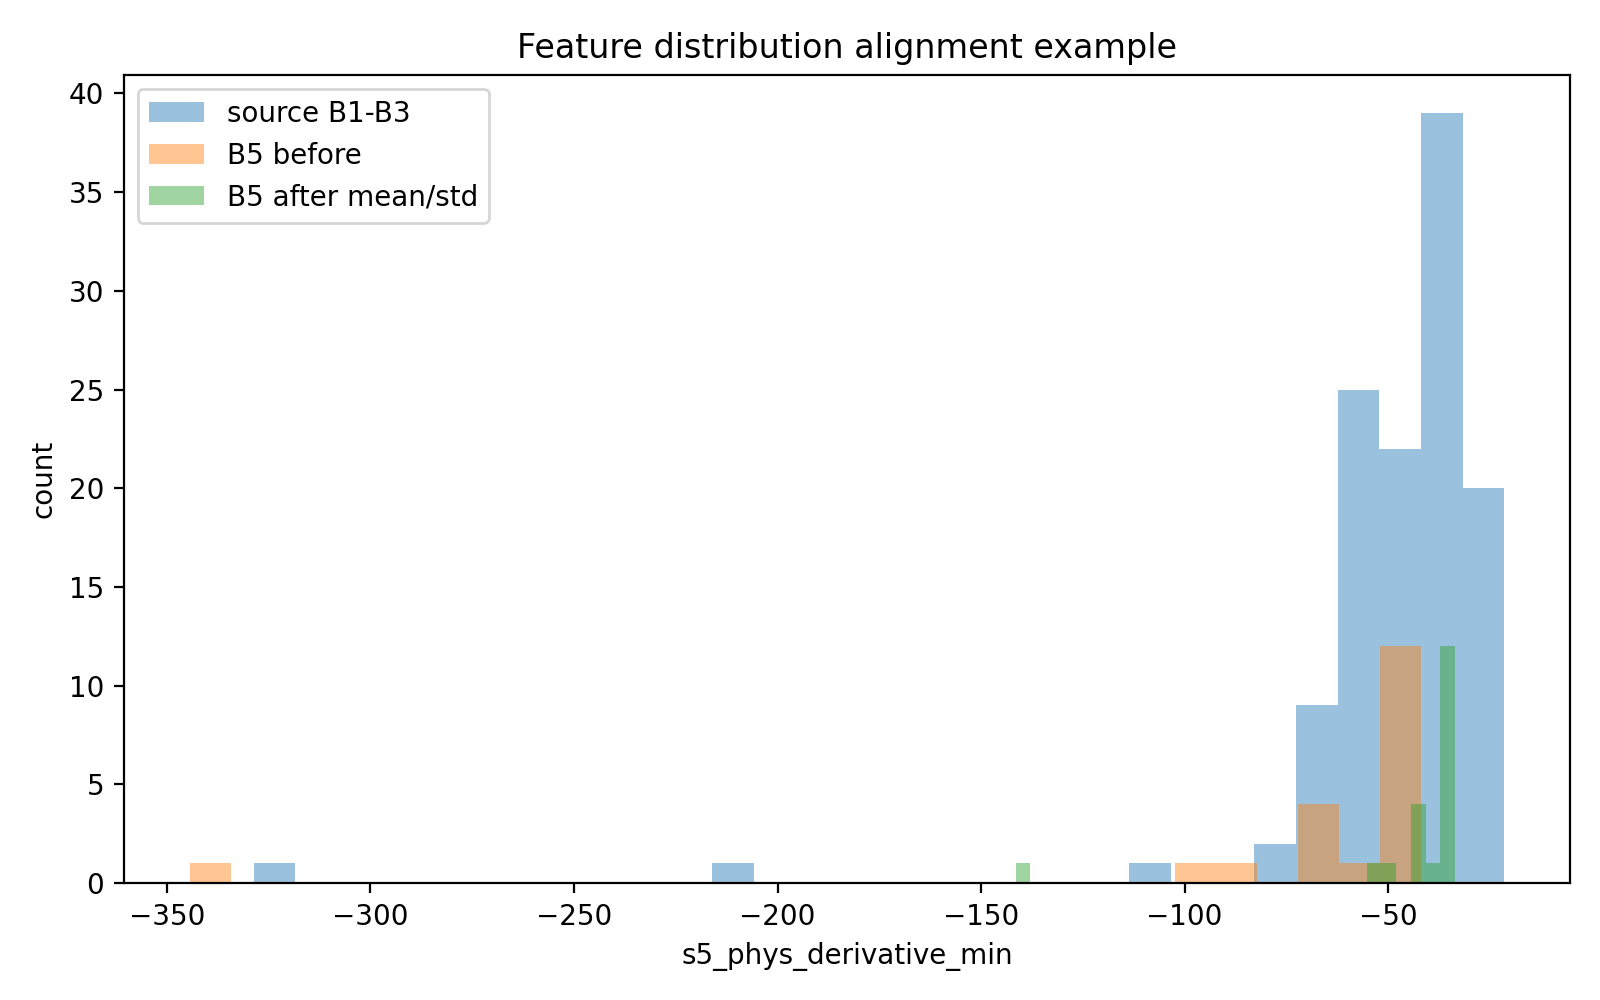


 residual_error_reduction.png


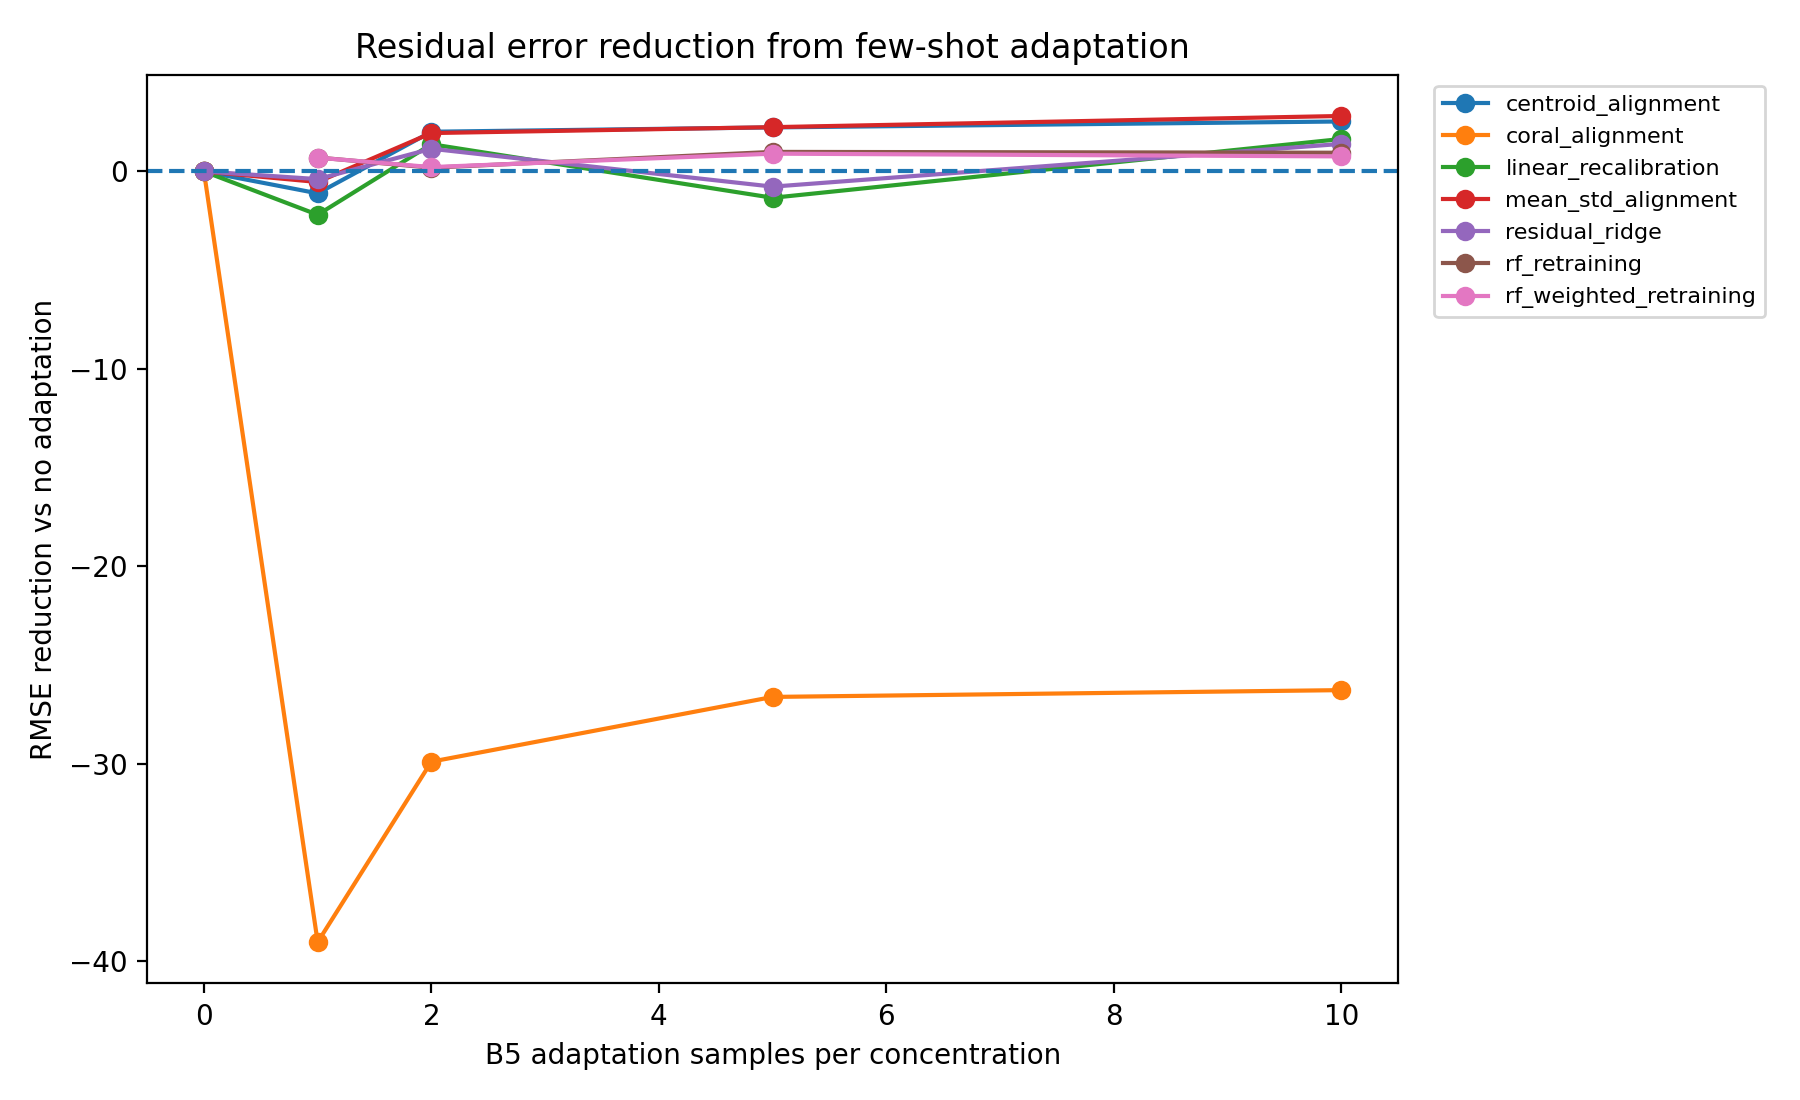


 high_concentration_improvement.png


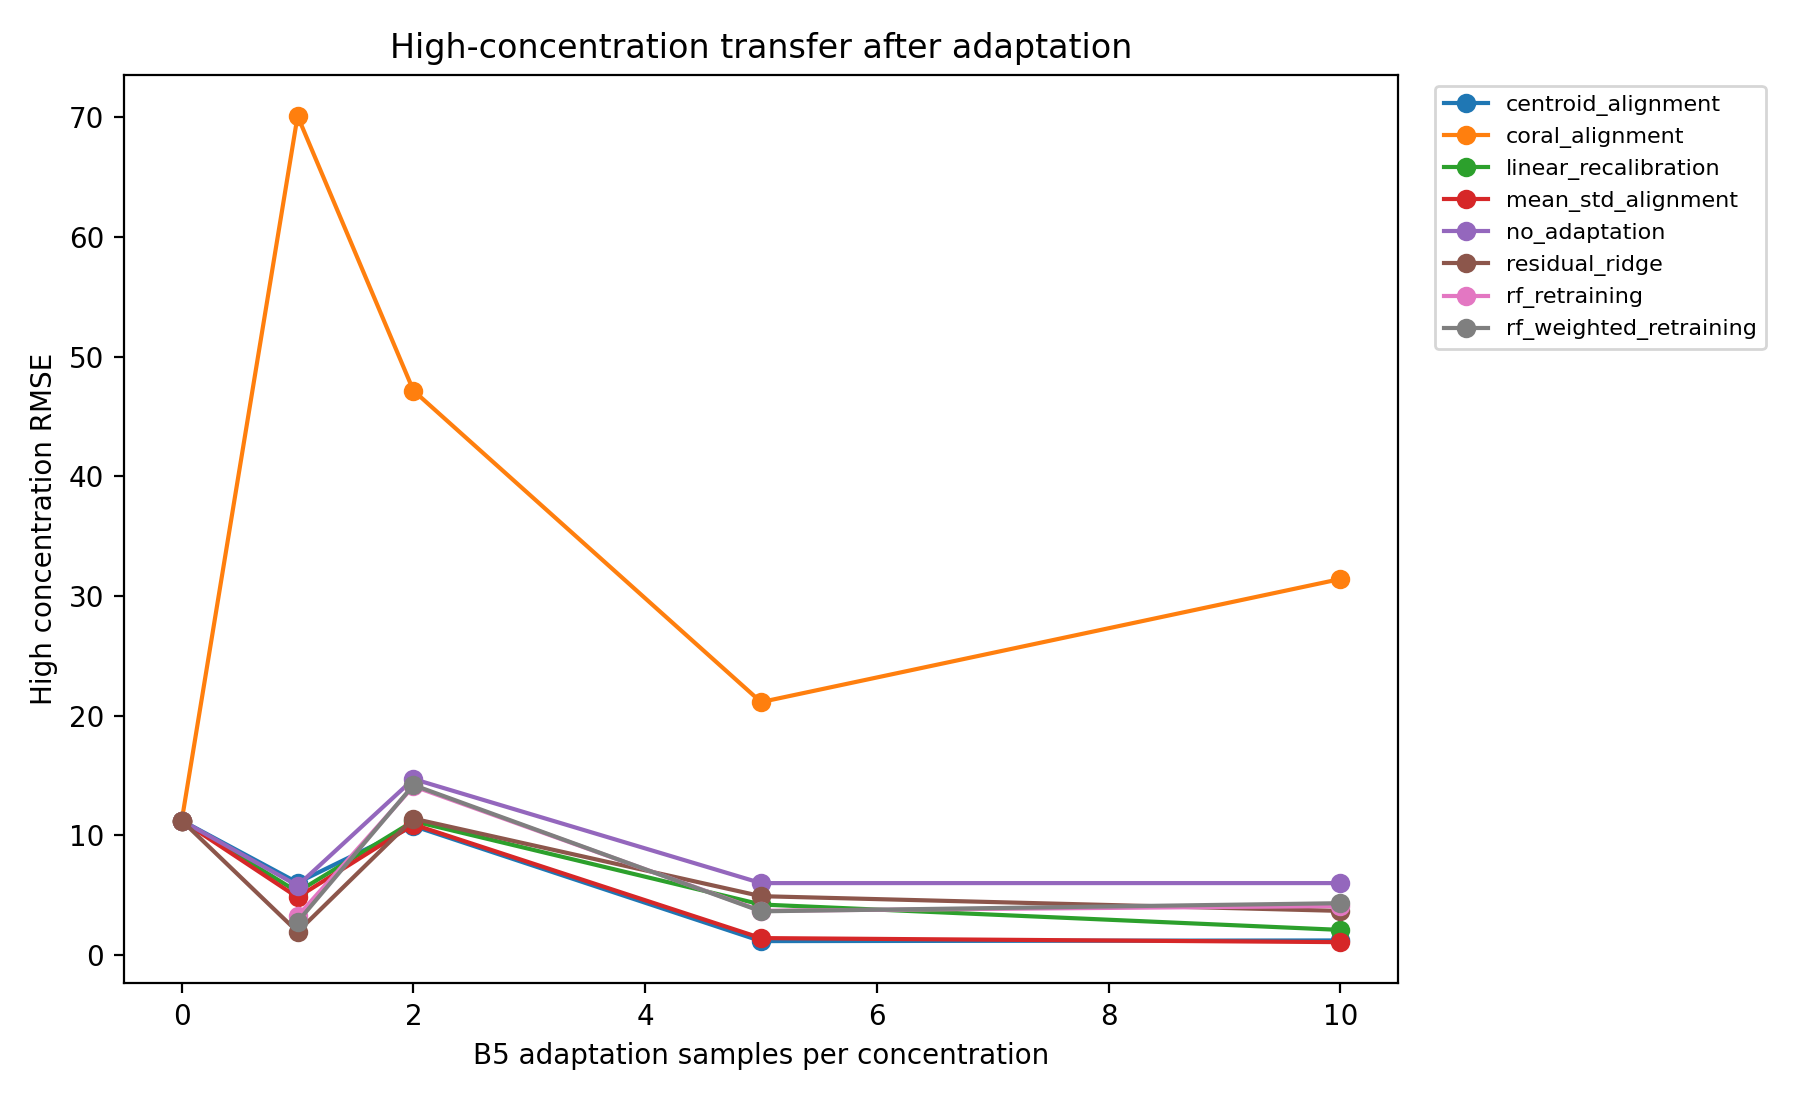


 confusion_matrix_best_adaptation.png


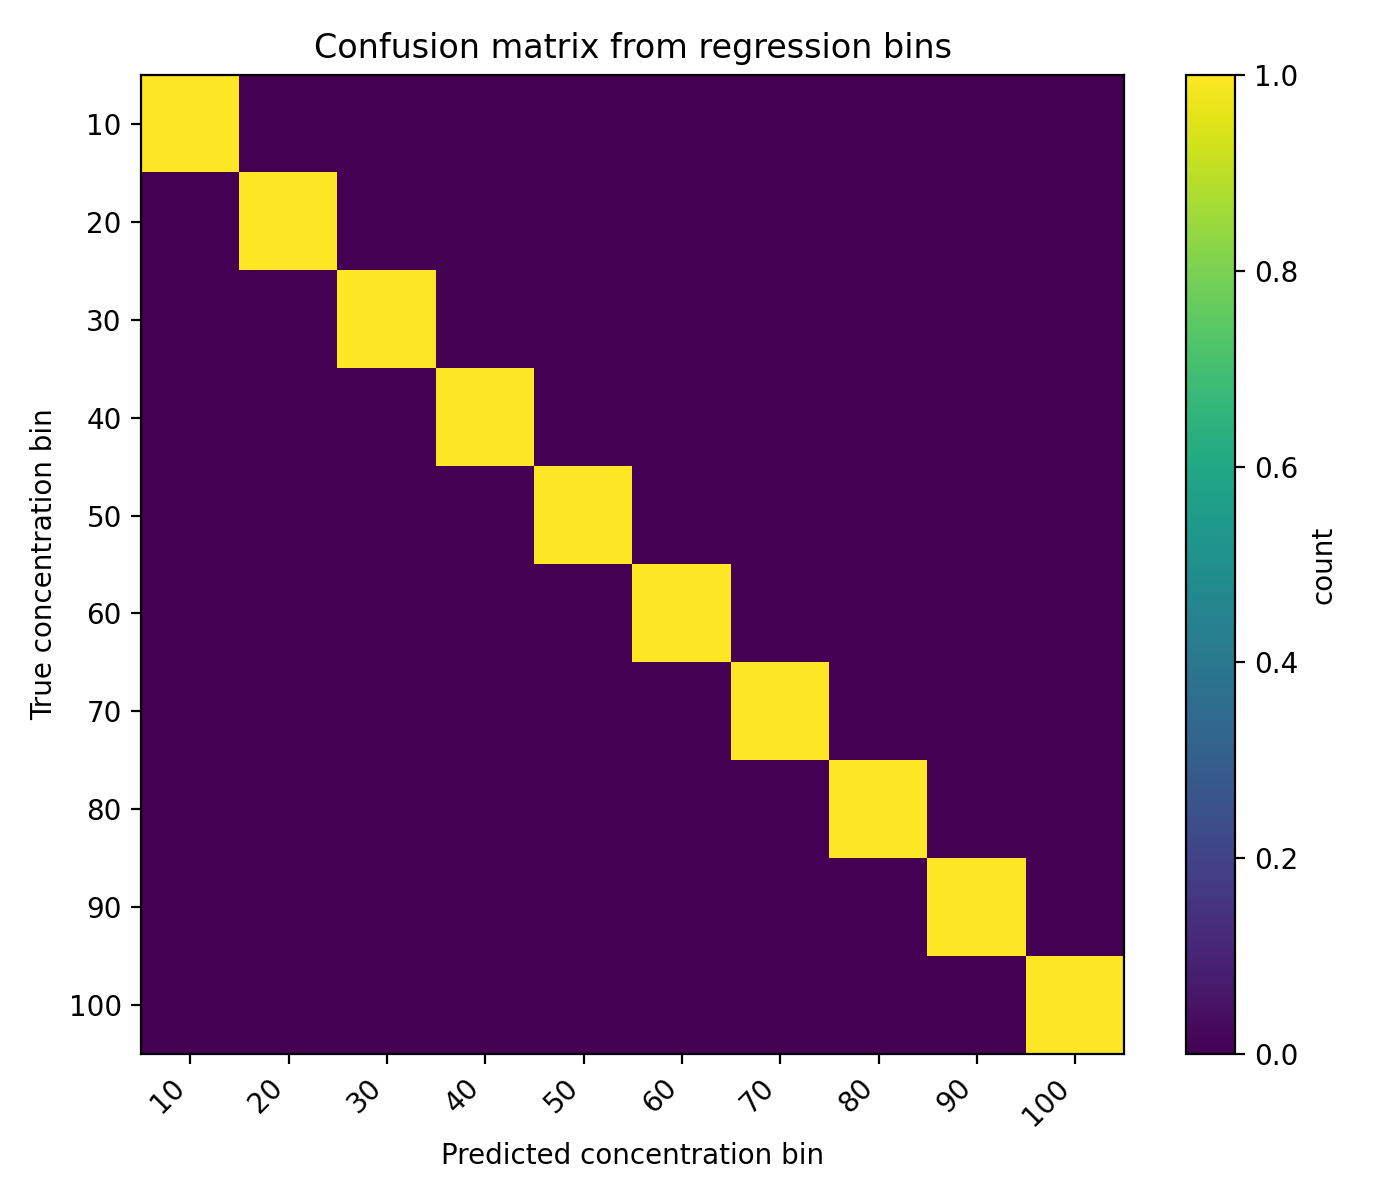

In [5]:
from IPython.display import Image, display
for name in [
    'rmse_vs_fewshot_samples.png',
    'prediction_vs_true_best_adaptation.png',
    'pca_before_adaptation.png',
    'pca_after_mean_std_alignment.png',
    'feature_distribution_alignment.png',
    'residual_error_reduction.png',
    'high_concentration_improvement.png',
    'confusion_matrix_best_adaptation.png',
]:
    path = PROJECT_ROOT / 'figures/day3' / name
    if path.exists():
        print('\n', name)
        display(Image(filename=str(path)))
    else:
        print('Missing:', path)

## Concise scientific summary

In [6]:
from pathlib import Path
obs = PROJECT_ROOT / 'results/day3/day3_observations.md'
print(obs.read_text(encoding='utf-8') if obs.exists() else 'Observation file not found.')

# Day 3 Observations: Few-shot B5 Adaptation

- Target variable inferred: `concentration_numeric`.
- Primary feature mode: physics-informed / numeric selected features, n = 89.
- Source training boards: B1/B2/B3; target transfer board: B5; B5 holdout labels are never used for fitting.
- 0-shot baseline RMSE: 6.346; MAE: 3.635; R²: 0.9512.

## Best method by few-shot size

- 0-shot: `centroid_alignment` | RMSE=6.346, MAE=3.635, R²=0.9512, high-conc RMSE=11.23.
- 1-shot: `rf_retraining` | RMSE=2.61, MAE=1.957, R²=0.9917, high-conc RMSE=3.227.
- 2-shot: `centroid_alignment` | RMSE=6.102, MAE=3.451, R²=0.9549, high-conc RMSE=10.77.
- 5-shot: `mean_std_alignment` | RMSE=1.172, MAE=0.9325, R²=0.9983, high-conc RMSE=1.401.
- 10-shot: `mean_std_alignment` | RMSE=1.026, MAE=0.8453, R²=0.9987, high-conc RMSE=1.063.

## Concise scientific summary

- Most effective observed adaptation: `mean_std_alignment` at 10-shot per concentration.
- Linear/recalibration-style methods test whether B5 mainly ha

## Output files

Saved outputs:

- `results/day3/day3_adaptation_metrics.csv`
- `results/day3/day3_predictions.csv`
- `results/day3/day3_feature_columns.csv`
- `results/day3/day3_confusion_matrix_best.csv`
- `results/day3/day3_observations.md`
- `figures/day3/*.png`